# Moving Average Crossover Backtest: AAPL

This is a small project where I test a simple trading strategy against AAPL stock data from 2019 to 2026, and compare it to just buying and holding the stock.

The strategy is based on moving average crossovers, when a short-term average price crosses above a long-term average price, that is treated as a buy signal and when it crosses below, that's a sell signal. It is one of the most common beginner strategies in trading.

**What I did:**

- Pulled AAPL price data
- Calculated a 20-day and 50-day moving average
- Built buy/sell signals based on when they cross
- Compared the strategy's returns against just holding the stock
- Checked max drawdown to see which one was riskier

**Tools:** `yfinance`, `Pandas`, `NumPy`, `Matplotlib`

## Getting the data

I pulled daily AAPL price data from 2019 to early 2026 using yfinance, with `auto_adjust=True` so prices are split and dividend adjusted. This range covers a bunch of different market conditions, specifically the COVID-19 crash, 2022 downturn and even a long recovery, so it's a normal stretch to actually test a strategy on.


In [1]:
import yfinance as yf
import pandas as pd

raw = yf.download("AAPL", start="2019-01-01", end="2026-01-01", auto_adjust=True)

# yfinance returns MultiIndex columns, need to flatten.
# data = yf.download("AAPL", start="2019-01-01", end="2026-01-01")

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)


data = raw.copy()
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436913,37.657383,36.562151,36.718613,148158800
2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2019-01-04,35.146885,35.215635,34.089588,34.262643,234428400
2019-01-07,35.068653,35.282012,34.587417,35.251192,219111200
2019-01-08,35.737175,35.990834,35.208527,35.455070,164101200


## Moving averages

I calculated a 20day and a 50day moving average from the closing price. These two lines are what the whole strategy is built on.

In [2]:
SHORT_WINDOW = 20
LONG_WINDOW = 50

data['SMA_short'] = data['Close'].rolling(window=SHORT_WINDOW).mean()
data['SMA_long'] = data['Close'].rolling(window=LONG_WINDOW).mean()
data.tail()

Price,Close,High,Low,Open,Volume,SMA_short,SMA_long
Date,,,,,,,
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600,276.399652,270.219039
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800,276.192714,270.703749
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,275.938907,271.233300
2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600,275.439267,271.652845
2025-12-31,271.122009,272.937076,271.012322,272.318764,27293600,274.724712,271.849788


## Building the signal

This is the actual strategy logic. If the 20day average is above the 50day average, the signal is 1, meaning I'd be holding the stock. If it's below, the signal is 0, meaning I'd be sitting out in cash.

During the first 49 days, `SMA_long` hasn't warmed up yet, so those rows are dropped below rather than silently treated as "sit out".

In [3]:
data['Signal'] = (data['SMA_short'] > data['SMA_long']).astype(int)

# drop the warm-up period so both curves start from the start date
data = data.dropna(subset=['SMA_long']).copy()

# data.loc[data['SMA_short'] > data['SMA_long'], 'Signal'] = 1


data[[ 'Close', 'SMA_short', 'SMA_long', 'Signal']].tail(10)

Price,Close,SMA_short,SMA_long,Signal
Date,,,,
2025-12-17,271.102051,276.209666,267.996821,1
2025-12-18,271.451111,276.390674,268.283639,1
2025-12-19,272.927124,276.760667,268.680081,1
2025-12-22,270.234467,276.734740,269.197424,1
2025-12-23,271.620667,276.557222,269.694867,1
2025-12-24,273.066742,276.399652,270.219039,1
2025-12-26,272.657806,276.192714,270.703749,1
2025-12-29,273.016876,275.938907,271.233300,1
2025-12-30,272.338684,275.439267,271.652845,1


## Calculating returns

Daily returns are calculated from the closing price. The strategy earns that return only when the previous day's signal is 1, the signal from the close of day *t-1* is used to determine the position held from close *t-1* to close *t*. This avoids look ahead bias, since the position is based on information already known at the start of the period being measured.

When the strategy is out of the market (Signal = 0), this version assumes cash earns a small daily risk-free rate rather than exactly 0%, leaving it at 0% would understate the strategy's real world return, since T-bills have paid a meaningful yield for a lot of this period.

In [4]:
RISK_FREE_ANNUAL = 0.04 # rough approximation, T-bill yield varies over the period
rf_daily = RISK_FREE_ANNUAL / 252

data['Daily_Return'] = data['Close'].pct_change()
position = data['Signal'].shift(1)
data['Strategy_Return'] = data['Daily_Return'] * position + rf_daily * (1 - position)

#data['Strategy_Return'] = data['Daily_Return'] * data['Signal'].shift(1)
data[['Close', 'Signal', 'Daily_Return', 'Strategy_Return']].tail(10)


Price,Close,Signal,Daily_Return,Strategy_Return
Date,,,,
2025-12-17,271.102051,1,-0.010087,-0.010087
2025-12-18,271.451111,1,0.001288,0.001288
2025-12-19,272.927124,1,0.005437,0.005437
2025-12-22,270.234467,1,-0.009866,-0.009866
2025-12-23,271.620667,1,0.005130,0.005130
2025-12-24,273.066742,1,0.005324,0.005324
2025-12-26,272.657806,1,-0.001498,-0.001498
2025-12-29,273.016876,1,0.001317,0.001317
2025-12-30,272.338684,1,-0.002484,-0.002484


## Adding it all up

This compounds the daily returns over time, so I can see how $1 would have grown if I just held the stock versus if I followed the strategy the whole way through.

In [5]:
data['Cumulative_Market_Return'] = (1 + data['Daily_Return']).cumprod()
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()
data[['Cumulative_Market_Return', 'Cumulative_Strategy_Return']].tail(10)

Price,Cumulative_Market_Return,Cumulative_Strategy_Return
Date,,
2025-12-17,6.197709,3.368960
2025-12-18,6.205689,3.373298
2025-12-19,6.239433,3.391640
2025-12-22,6.177875,3.358179
2025-12-23,6.209566,3.375405
2025-12-24,6.242624,3.393375
2025-12-26,6.233276,3.388294
2025-12-29,6.241485,3.392756
2025-12-30,6.225980,3.384328


## Plotting it out

This graph shows both return curves. The strategy line is flatter as it spends real time out of the market, which caps both its losses and its gains. The gaps between the two lines widen sharply during the strongest recovery stretches (2023 and 2024-25), since that's exactly when the strategy tends to be lagging back into a position rather than already in it.

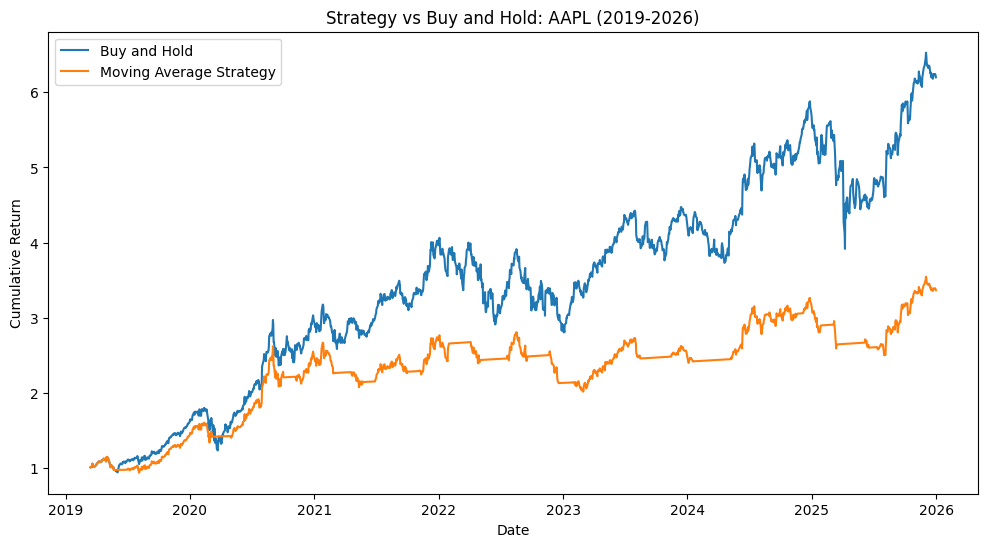

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['Cumulative_Market_Return'], label='Buy and Hold')
plt.plot(data['Cumulative_Strategy_Return'], label='Moving Average Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs Buy and Hold: AAPL (2019-2026)')
plt.legend()
plt.show()

## Seeing the whipsaws directly

The graph shows overall performance, but not *why* the strategy underperforms. This next plot overlays both moving averages on price itself, with the periods the strategy was actually in the market shaded, this makes the whipsaw effect visible directly, rather than just inferred from the return gap.

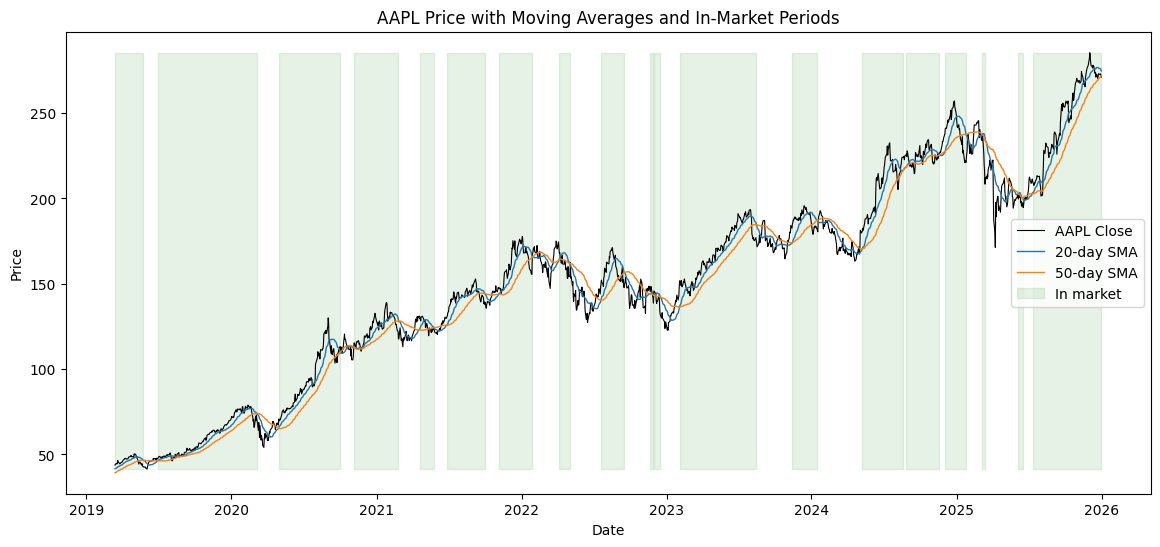

In [7]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(data['Close'], label='AAPL Close', color='black', linewidth=0.8)
ax.plot(data['SMA_short'], label=f'{SHORT_WINDOW}-day SMA', linewidth=1)
ax.plot(data['SMA_long'], label=f'{LONG_WINDOW}-day SMA', linewidth=1)
ax.fill_between(data.index, data['Close'].min(), data['Close'].max(),
                where=data['Signal']==1, alpha=0.1, color='green', label='In market')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title('AAPL Price with Moving Averages and In-Market Periods')
ax.legend()
plt.show()

## Checking the risk side

Returns aren't the whole story, a strategy that makes less money but also loses less during a crash can still be worth something. Max drawdown shows the biggest drop each approach took from its peak.

Buy and Hold  -  CAGR: 30.82%, Max Drawdown: -33.36%, Sharpe: 0.89
Strategy      -  CAGR: 19.59%, Max Drawdown: -28.15%, Sharpe: 0.75


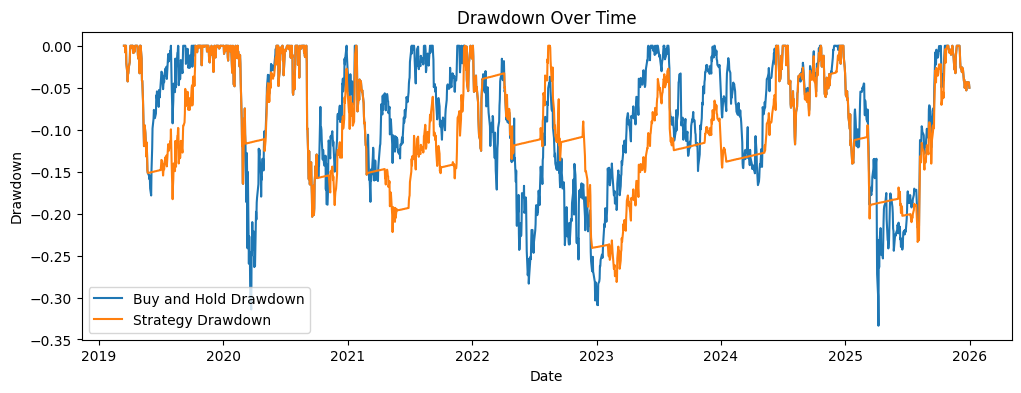

In [8]:
def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown, drawdown.min()

def cagr(cumulative_returns, periods_per_year=252):
    n_years = len(cumulative_returns) / periods_per_year
    return cumulative_returns.iloc[-1] ** (1 / n_years) - 1

def sharpe(daily_returns, rf_daily, periods_per_year=252):
    excess = daily_returns - rf_daily
    return (excess.mean() / excess.std()) * (periods_per_year ** 0.5)

market_drawdown_series, market_dd = max_drawdown(data['Cumulative_Market_Return'])
strategy_drawdown_series, strategy_dd = max_drawdown(data['Cumulative_Strategy_Return'])

market_cagr = cagr(data['Cumulative_Market_Return'])
strategy_cagr = cagr(data['Cumulative_Strategy_Return'])

market_sharpe = sharpe(data['Daily_Return'].dropna(), rf_daily)
strategy_sharpe = sharpe(data['Strategy_Return'].dropna(), rf_daily)

print(f"Buy and Hold  -  CAGR: {market_cagr:.2%}, Max Drawdown: {market_dd:.2%}, Sharpe: {market_sharpe:.2f}")
print(f"Strategy      -  CAGR: {strategy_cagr:.2%}, Max Drawdown: {strategy_dd:.2%}, Sharpe: {strategy_sharpe:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(market_drawdown_series, label='Buy and Hold Drawdown')
ax.plot(strategy_drawdown_series, label='Strategy Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.set_title('Drawdown Over Time')
ax.legend()
plt.show()

## Assumptions and limitations

 - No transaction costs or slippage and every crossover is assumed to trade for free
 - Long/flat only - no short positions
 - Full capital committed on every trade, no partial position sizing
 - Cash return while out of the market is approximated at a flat 4% annual rate, not the actual historical T-bill rate at each point in time
 - Fills happen at the closing price of the signal day, not the next day's open
 - Single ticker, single parameter pair (20/50) - not tested for robustness across stocks or window lengths

## What I found

Buy and hold clearly won on returns — $1 turned into about $6.24, versus $3.37 with the strategy. But raw returns alone are misleading here, since the strategy spends real time out of the market and has much lower exposure by construction. Looking at it risk-adjusted tells a sharper story:

| | CAGR | Max Drawdown | Sharpe |
|---|---|---|---|
| Buy & Hold | 30.82% | -33.36% | 0.89 |
| Strategy | 19.59% | -28.15% | 0.75 |

The strategy bought a modest drawdown improvement (about 5 percentage points) at the cost of giving up roughly a third of its annual growth rate. On a risk-adjusted basis, it isn't close — buy-and-hold wins decisively, not just on absolute return.

This tracks with what's expected: simple moving average strategies tend to get whipsawed out of the market during choppy stretches and miss the sharp early days of recoveries, which adds up significantly over a long bull run like AAPL's. It's also worth noting AAPL was not a neutral pick — it grew substantially over this window, which stacks the deck toward buy-and-hold before the strategy is even tested.

## Where this could go further

This strategy is about as simple as trend following is, and that's kind of the whole point. A few things this could get meaningfully more advanced:

- **Parameter and universe robustness testing:** right now this is one asset and one parameter pair, a sample size of one. Testing the same strategy across a bunch of different stocks and window combinations would show whether this result actually holds up generally, or if it's just specific to AAPL's exact price path over this exact period.

- **Multiple signals combined:** real strategies rarely rely on just one indicator. Adding something like RSI or volume based confirmation could reduce false signals during choppy periods.

- **Position sizing:** right now the strategy is either fully in or fully out. A more advanced version might scale position size based on signal strength or volatility, rather than a hard on/off switch.

- **Different asset classes:** trend following strategies like this tend to perform better in commodities or currency markets than in a single high growth stock like AAPL, since those markets often have longer and cleaner trends.

- **Machine learning based signals:** instead of a fixed rule like moving average crossover, a model could be trained to learn more complex, non linear patterns in price behavior, which is closer to how real quant research approaches signal generation.

This project was meant to be a clear, understandable first step into backtesting rather than a genuinely competitive strategy, but these are the directions that are worth exploring.